# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import * 
from core.segment_targeting_estimators import *
from core.dgp import *
from core.segment_targeting_experiments import *

import core.binary_treatment_multiple_segments as btms

# DGP

In [6]:
dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 1.0, 
}

dgp = MultipleSegments(**dgp_params)

In [7]:
segment_arr, treatment_arr, outcome_arr = dgp.sample(600, seed=0)

# Demand Model

In [8]:
te_est_arr = btms.segment_difference_in_mean(segment_arr, treatment_arr, outcome_arr)

for segment in dgp.segment_arr:
    print(f'Segment {segment}: True TE: {dgp.segment_te_arr[segment]:.2f}, Estimated TE: {te_est_arr[segment]:.2f}')

Segment 0: True TE: 0.05, Estimated TE: 0.05
Segment 1: True TE: 0.10, Estimated TE: 0.06


# Optimization

In [9]:
# sample customers to target
targ_customers = dgp.sample_individuals(100, seed=10)

# optimize the targeting strategy
plugin_decision, plugin_val_est = btms.optimize(
    targ_customers, te_est_arr, 10
)

# calculate the value of the objective function
true_plugin_val = btms.obj_func(
    targ_customers, dgp.segment_te_arr, plugin_decision
)

print('Estimated plugin policy value:', plugin_val_est)
print('True plugin policy value:', true_plugin_val)

Estimated plugin policy value: 0.6193793558496603
True plugin policy value: 1.0


# Winner's Curse

In [12]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 3.0, 
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {'n_experiments': 1000}

estimators_dict = {}

result_records = btms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    verbose=1, n_jobs=-1
)

emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc'] / record['clairvoyant_val'] for record in result_records])

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


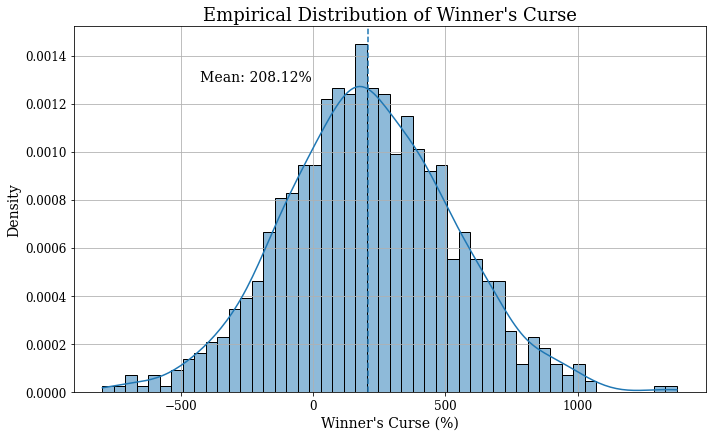

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_pct_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(emp_wc_pct_dstn_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {emp_wc_pct_dstn_arr.mean():.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [15]:
dgp = MultipleSegments(**dgp_params)
segment_arr, treatment_arr, outcome_arr = dgp.sample(data_params['sample_size'], seed=0)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=1)

## Standard Bootstrap

In [16]:
boot_wc_dstn_arr = btms.get_wc_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


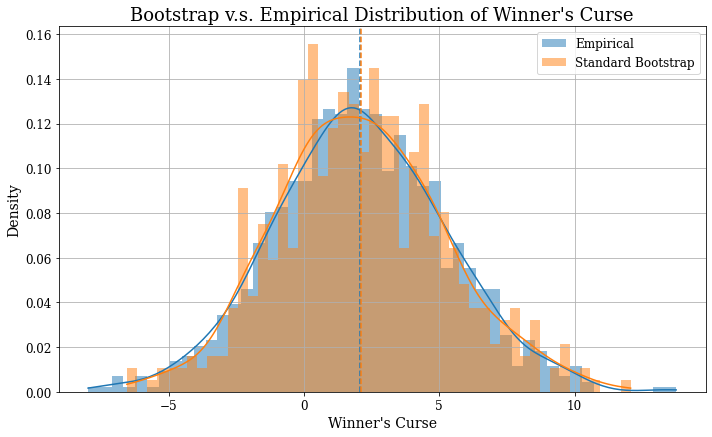

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical', edgecolor=None)
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap', edgecolor=None)
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [18]:
mn_boot_wc_dstn_arr = btms.get_wc_m_out_of_n_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, power=0.95, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


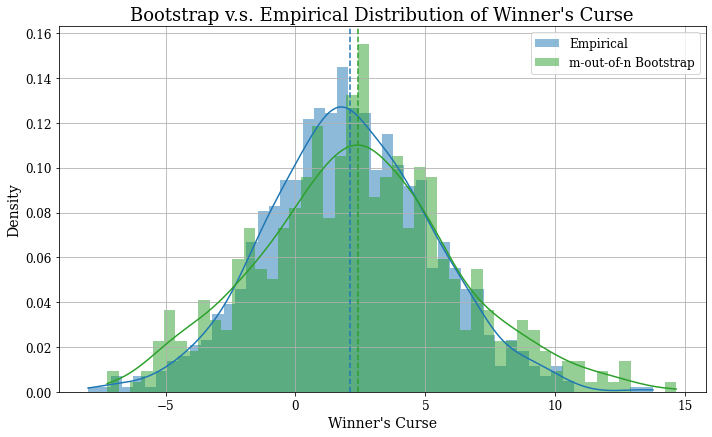

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical', edgecolor=None)
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap', edgecolor=None)
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [20]:
num_boot_wc_dstn_arr = btms.get_wc_num_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    budget=operations_params['budget'], 
    n_bootstraps=500, power=-0.45, 
    n_jobs=-1, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


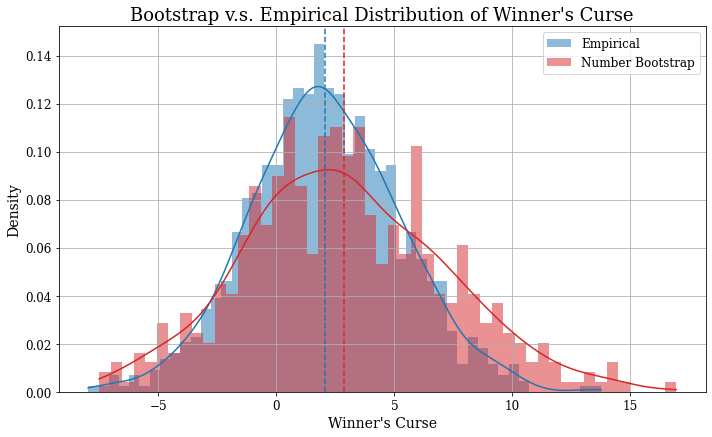

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical', edgecolor=None)
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Number Bootstrap', edgecolor=None)
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title('Bootstrap v.s. Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.legend(fontsize=legend_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [22]:
del dgp, segment_arr, treatment_arr, outcome_arr, targ_customers
del emp_wc_dstn_arr, emp_wc_pct_dstn_arr, boot_wc_dstn_arr, mn_boot_wc_dstn_arr, num_boot_wc_dstn_arr

# Bias Correction

In [27]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 3.0, 
}

data_params = {'sample_size': 600, 'n_customers': 100}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 600, 'bootstrap_method': 'standard', 'n_jobs': 1, }
    }, 
    'mn_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1, 
        }
    }, 
    'num_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1, 
        }
    }
}

In [28]:
result_records = btms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   49.3s finished


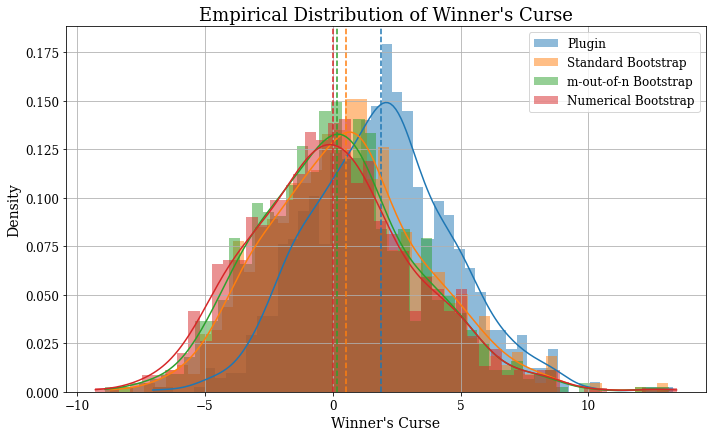

In [29]:
result_df = pd.DataFrame.from_records(result_records)
result_df = result_df[[col for col in result_df if col.endswith('wc')]]

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# historgram of plugin estimator's winner's curse
sns.histplot(result_df['plugin_wc'], bins=50, kde=True, stat='density', ax=ax, color='C0', edgecolor=None, label='Plugin')
ax.axvline(result_df['plugin_wc'].mean(), color='C0', linestyle='--')

# historgram of standard bootstrap estimator's winner's curse
sns.histplot(result_df['stand_bootstrap_wc'], bins=50, kde=True, stat='density', ax=ax, color='C1', edgecolor=None, label='Standard Bootstrap')
ax.axvline(result_df['stand_bootstrap_wc'].mean(), color='C1', linestyle='--')

# historgram of m-out-of-n bootstrap estimator's winner's curse
sns.histplot(result_df['mn_bootstrap_wc'], bins=50, kde=True, stat='density', ax=ax, color='C2', edgecolor=None, label='m-out-of-n Bootstrap')
ax.axvline(result_df['mn_bootstrap_wc'].mean(), color='C2', linestyle='--')

# historgram of numerical bootstrap estimator's winner's curse
sns.histplot(result_df['num_bootstrap_wc'], bins=50, kde=True, stat='density', ax=ax, color='C3', edgecolor=None, label='Numerical Bootstrap')
ax.axvline(result_df['num_bootstrap_wc'].mean(), color='C3', linestyle='--')

ax.set_title('Empirical Distribution of Winner\'s Curse', fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [31]:
for estimator in estimators_dict.keys():
    avg_wc = result_df[f'{estimator}_wc'].mean()
    se_wc = result_df[f'{estimator}_wc'].std() / np.sqrt(data_params['sample_size'])
    print(f'{estimator} Winner\'s Curse: {avg_wc:.2f} ({se_wc:.2f})')

stand_bootstrap Winner's Curse: 0.53 (0.13)
mn_bootstrap Winner's Curse: 0.17 (0.13)
num_bootstrap Winner's Curse: 0.01 (0.13)


# Sensitivity Analysis

## Sample Size

In [32]:
operations_params = {'budget': 10}

dgp_params = {
    'n_segments': 2, 
    'te': 0.05,
    'treatment_space': np.array([0, 1]), 
    'noise_std': 3.0, 
}

data_params = {'sample_size': np.nan, 'n_customers': 100}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'stand_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1, }
    }, 
    'mn_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1, 
        }
    }, 
    'num_bootstrap': {
        'estimator': btms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1, 
        }
    }
}

In [33]:
sample_size_result_dict = btms.sample_size_test(
    sample_sizes=[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000],
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
    save_path='results/case3_sample_size_test.pkl'
)


Running sample size 100 (1/14)
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   23.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   28.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 100 in 0:00:28.049058

Running sample size 200 (2/14)
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   27.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 200 in 0:00:27.120526

Running sample size 300 (3/14)
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   26.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


Finished sample size 4000 in 0:02:25.539848

Running sample size 5000 (14/14)
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   33.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  2.4min


Finished sample size 5000 in 0:03:02.178389


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.0min finished


In [34]:
with open('results/case3_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

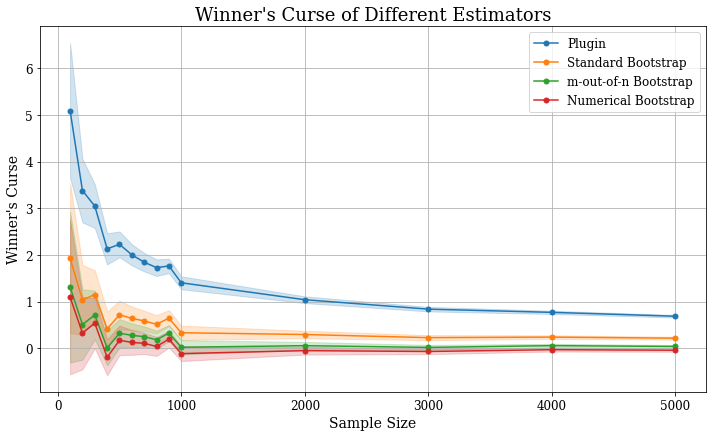

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_mean'] - 1.96 * result_df['plugin_wc_se'],
    result_df['plugin_wc_mean'] + 1.96 * result_df['plugin_wc_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_wc_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['stand_bootstrap_wc_mean'] - 1.96 * result_df['stand_bootstrap_wc_se'],
    result_df['stand_bootstrap_wc_mean'] + 1.96 * result_df['stand_bootstrap_wc_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_mean'] - 1.96 * result_df['mn_bootstrap_wc_se'], 
    result_df['mn_bootstrap_wc_mean'] + 1.96 * result_df['mn_bootstrap_wc_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_mean'] - 1.96 * result_df['num_bootstrap_wc_se'], 
    result_df['num_bootstrap_wc_mean'] + 1.96 * result_df['num_bootstrap_wc_se'], 
    color='C3', alpha=0.2
)


ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case3-sample-size-test.png')
plt.show()

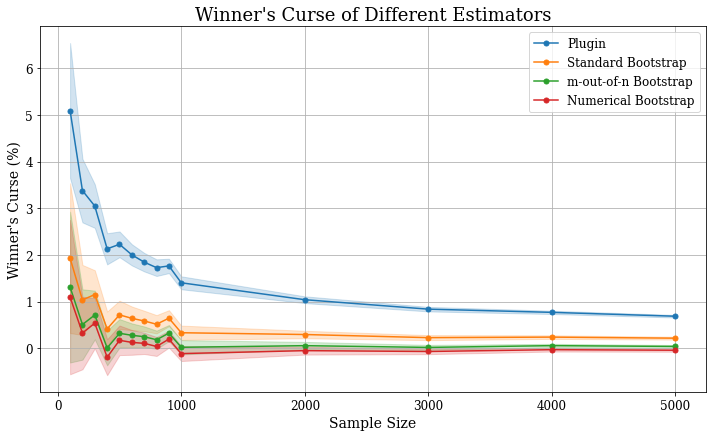

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_wc_pct_mean'], 'o-', markersize=5, label='Plugin', color='C0')
ax.fill_between(
    result_df.index, 
    result_df['plugin_wc_pct_mean'] - 1.96 * result_df['plugin_wc_pct_se'],
    result_df['plugin_wc_pct_mean'] + 1.96 * result_df['plugin_wc_pct_se'],
    color='C0', alpha=0.2
)

# standard bootstrap 
ax.plot(result_df.index, result_df['stand_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
ax.fill_between(
    result_df.index,
    result_df['stand_bootstrap_wc_pct_mean'] - 1.96 * result_df['stand_bootstrap_wc_pct_se'],
    result_df['stand_bootstrap_wc_pct_mean'] + 1.96 * result_df['stand_bootstrap_wc_pct_se'],
    color='C1', alpha=0.2
)

# m out of n bootstrap
ax.plot(result_df.index, result_df['mn_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
ax.fill_between(
    result_df.index, 
    result_df['mn_bootstrap_wc_pct_mean'] - 1.96 * result_df['mn_bootstrap_wc_pct_se'], 
    result_df['mn_bootstrap_wc_pct_mean'] + 1.96 * result_df['mn_bootstrap_wc_pct_se'], 
    color='C2', alpha=0.2
)

# numerical bootstrap
ax.plot(result_df.index, result_df['num_bootstrap_wc_pct_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
ax.fill_between(
    result_df.index, 
    result_df['num_bootstrap_wc_pct_mean'] - 1.96 * result_df['num_bootstrap_wc_pct_se'], 
    result_df['num_bootstrap_wc_pct_mean'] + 1.96 * result_df['num_bootstrap_wc_pct_se'], 
    color='C3', alpha=0.2
)

ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
# plt.savefig('figures/case3-sample-size-test.png')
plt.show()